## **Q3. What is the ratio of learners with diagnosed disabilities and recorded manifestations to each existing SPED Center or ILRC, by municipality and disability type? How about relative to SPED plantilla positions for teachers?**

**Datasets used in this notebook**

| File | Role |
|---|---|
| `sned_database_tidy_long.parquet` | SNED learner counts by school, disability category, diagnosis type, grade, and sex. Queried through DuckDB throughout so the raw table is never loaded into pandas. |
| `sned_facility_roster.csv` | Per-school ILRC / SPED Center / SNED-implementing tags, used to build municipality- and division-level facility counts. |
| `[3.2] Number of Receiving Teachers Handling SPED Classes_051325.xlsx` | "By SDO_Positions" sheet — general-education teachers handling SPED classes **without** an official plantilla item, by region/division. |
| `[3.3] Status of Filling Up_SNED Teaching Items.xlsx` | Two distinct roles from two sheet groups: (a) "ES/JHS SNED shortage" sheets → school-level SNED NG enrollment + SPED teacher inventory/shortage headcounts; (b) "Filling up Status" sheet → division-level authorized/filled/unfilled SPED plantilla items (positions). |
| `public_school_coordinates.parquet` | School-level PSGC geography (region/province/municipality) for public schools. |

### **A. Preliminaries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import geopandas as gpd
import duckdb
pd.set_option('display.max_columns', None)

REGION_SHORT = {
    'Region I (Ilocos Region)':       'Ilocos Region',
    'Region II (Cagayan Valley)':     'Cagayan Valley',
    'Cordillera Administrative Region (CAR)': 'CAR',
    'Region III (Central Luzon)':     'Central Luzon',
    'National Capital Region (NCR)':  'NCR',
    'Region IV-A (CALABARZON)':       'CALABARZON',
    'MIMAROPA Region':                'MIMAROPA',
    'Region V (Bicol Region)':        'Bicol Region',
    'Region VI (Western Visayas)':    'Western Visayas',
    'Negros Island Region (NIR)':     'NIR',
    'Region VII (Central Visayas)':   'Central Visayas',
    'Region VIII (Eastern Visayas)':  'Eastern Visayas',
    'Region IX (Zamboanga Peninsula)':'Zamboanga Peninsula',
    'Region X (Northern Mindanao)':   'Northern Mindanao',
    'Region XI (Davao Region)':       'Davao Region',
    'Region XII (SOCCSKSARGEN)':      'SOCCSKSARGEN',
    'Region XIII (Caraga)':           'Caraga',
    'Bangsamoro Autonomous Region In Muslim Mindanao (BARMM)': 'BARMM',
}
REGION_ORDER = list(REGION_SHORT.values())

REGION_CODE_LABELS = {
    'I': 'Ilocos Region', 'II': 'Cagayan Valley', 'III': 'Central Luzon',
    'IV-A': 'CALABARZON', 'IV-B': 'MIMAROPA', 'V': 'Bicol Region',
    'VI': 'Western Visayas', 'VII': 'Central Visayas', 'VIII': 'Eastern Visayas',
    'IX': 'Zamboanga Peninsula', 'X': 'Northern Mindanao', 'XI': 'Davao Region',
    'XII': 'SOCCSKSARGEN', 'XIII': 'Caraga', 'CARAGA': 'Caraga',
    'CAR': 'CAR', 'NCR': 'NCR', 'NIR': 'NIR', 'BARMM': 'BARMM',
}

from pyfonts import set_default_font, load_google_font
regular = load_google_font("Inter")
bold    = load_google_font("Inter", weight="bold")
set_default_font(regular)

_ROOT = Path.cwd().parent
DATA  = _ROOT / "data"

FACILITY_ROSTER_PATH = DATA / "sned_facility_roster.csv"
TEACHER_3_2_PATH     = DATA / "edcom" / "[3.2] Number of Receiving Teachers Handling SPED Classes_051325.xlsx"
TEACHER_3_3_PATH     = DATA / "edcom" / "[3.3] Status of Filling Up_SNED Teaching Items.xlsx"
SCHOOL_GEO_PATH      = DATA / "external" / "public_school_coordinates.parquet"
LEARNER_PARQUET_PATH = DATA / "sned_database_tidy_long.parquet"
SECTOR_FILTER = "Public"

# ---- PSGC / ID string handling -----------------------------------------
PSGC_ZFILL_WIDTH = 10
ID_LIKE_COLS    = ['school_id', 'psgc_region', 'psgc_province', 'psgc_municity', 'psgc_barangay']
PSGC_ZFILL_COLS = ['psgc_region', 'psgc_province', 'psgc_municity', 'psgc_barangay']

def cast_ids_to_str(df, cols=None, zfill_cols=None, zfill_width=PSGC_ZFILL_WIDTH):
    """Cast identifier-like columns to string; zero-pad psgc_* columns to full width.
    Float/int -> Int64 first (drops the trailing '.0' cleanly) -> string -> zfill.
    Verified NA-safe: NaN survives the whole chain as <NA>, not a literal string."""
    cols = cols or ID_LIKE_COLS
    zfill_cols = zfill_cols if zfill_cols is not None else PSGC_ZFILL_COLS
    df = df.copy()
    for c in cols:
        if c not in df.columns:
            continue
        if pd.api.types.is_float_dtype(df[c]) or pd.api.types.is_integer_dtype(df[c]):
            df[c] = df[c].astype('Int64').astype('string')
        else:
            df[c] = df[c].astype('string')
        if c in zfill_cols:
            df[c] = df[c].str.zfill(zfill_width)
    return df

def normalize_region_label(s):
    """3.2 ('By SDO_Positions') uses bare region codes ('I','II',...); 3.3 ('Filling up
    Status', ES/JHS SNED shortage) uses 'Region I','Region II',... Confirmed via direct
    inspection of both workbooks -- without this, any merge on 'region' between the two
    silently fails for every numbered region (only CAR/NCR/CARAGA would ever match)."""
    return s.astype(str).str.strip().str.replace(r'^Region\s+', '', regex=True)

# ---- Color scheme (Set2 pastel) -----
CAT_BASE      = plt.cm.Set2.colors[0]   # '#66c2a5' pastel green/teal
CAT_HIGHLIGHT = plt.cm.Set2.colors[1]   # '#fc8d62' pastel orange

In [2]:
# School-PSGC crosswalk from public_school_coordinates.parquet. 
school_geo_raw = pd.read_parquet(SCHOOL_GEO_PATH)
print(f"Loaded school_geo crosswalk: {school_geo_raw.shape[0]:,} rows")

_geo_cols = ["school_id", "psgc_region", "psgc_region_name", "psgc_province", "psgc_province_name",
             "psgc_municity", "psgc_municity_name", "urban_rural", "income_class"]
required = {"school_id", "psgc_municity", "psgc_municity_name", "psgc_province_name", "psgc_region_name"}
missing = required - set(school_geo_raw.columns)
assert not missing, f"school_geo_raw is missing expected columns: {missing}"

school_geo = (
    school_geo_raw[[c for c in _geo_cols if c in school_geo_raw.columns]]
    .dropna(subset=["school_id", "psgc_municity"])
)
school_geo = cast_ids_to_str(school_geo)
school_geo = school_geo.drop_duplicates("school_id")
print(f"Clean crosswalk: {len(school_geo):,} schools, {school_geo['psgc_municity'].nunique():,} municipalities")

muni_ref = (
    school_geo[["psgc_municity", "psgc_municity_name", "psgc_province_name", "psgc_region_name"]]
    .drop_duplicates("psgc_municity")
)

Loaded school_geo crosswalk: 48,254 rows
Clean crosswalk: 47,975 schools, 1,654 municipalities


In [3]:
# Facility rosters: two definitions
# Strict: ILRC + SPED Center; Inclusive: Strict + SNED-implementing schools
facility_roster = pd.read_csv(FACILITY_ROSTER_PATH)

facility_roster["is_facility_strict"]    = facility_roster["is_ilrc"] | facility_roster["is_sped_center"]
facility_roster["is_facility_incl_sned"] = facility_roster["is_facility_strict"] | facility_roster["is_sned"]

facility_roster_clean = facility_roster.dropna(subset=["psgc_municity"])
n_dropped = len(facility_roster) - len(facility_roster_clean)
if n_dropped:
    print(f"Facility roster: dropped {n_dropped} school(s) with no psgc_municity match")
facility_roster_clean = cast_ids_to_str(facility_roster_clean)

muni_facility = (
    facility_roster_clean
    .groupby("psgc_municity", as_index=False)
    .agg(n_ilrc=("is_ilrc", "sum"),
         n_sped_center=("is_sped_center", "sum"),
         n_sned_implementing=("is_sned", "sum"),
         n_facilities=("is_facility_strict", "sum"),
         n_facilities_incl_sned=("is_facility_incl_sned", "sum"))
)
print(muni_facility.shape)

Facility roster: dropped 4 school(s) with no psgc_municity match
(1094, 6)


In [4]:
# ES/JHS SNED shortage from [3.3] workbook
def load_sned_shortage_sheet(path, sheet_name, school_level_label):
    raw = pd.read_excel(path, sheet_name=sheet_name, header=5)
    raw = raw[raw["School ID"] != "TOTAL"].copy()
    raw["School ID"] = pd.to_numeric(raw["School ID"], errors="coerce")
    raw = raw.dropna(subset=["School ID"])  # also removes the stray 'x' footer rows

    raw = raw.rename(columns={
        "School ID": "school_id", "School Name": "school_name",
        "Region": "region", "Division": "division", "Province": "province",
        "Municipality": "municipality", "District": "district", "Barangay": "barangay",
        "Modified Curricular Offering Classification": "modified_coc",
    })
    raw = cast_ids_to_str(raw, cols=["school_id"], zfill_cols=[])

    rename_map = {}
    for col in raw.columns:
        lc = str(col).lower()
        if "enrollment" in lc:
            rename_map[col] = "sned_ng_enrollment"
        elif "teacher inventory" in lc:
            rename_map[col] = "sned_teacher_inventory"
        elif "teacher shortage" in lc:
            rename_map[col] = "sned_teacher_shortage"
    raw = raw.rename(columns=rename_map)

    for c in ["sned_ng_enrollment", "sned_teacher_inventory", "sned_teacher_shortage"]:
        coerced = pd.to_numeric(raw[c], errors="coerce")
        n_bad = coerced.isna().sum() - raw[c].isna().sum()
        if n_bad > 0:
            print(f"[{sheet_name}] {c}: coerced {n_bad} non-numeric value(s) to 0")
        raw[c] = coerced.fillna(0)

    keep = ["school_id", "school_name", "region", "division", "province", "municipality",
            "district", "barangay", "modified_coc",
            "sned_ng_enrollment", "sned_teacher_inventory", "sned_teacher_shortage"]
    out = raw[keep].copy()
    out["school_level"] = school_level_label
    return out

es_teachers  = load_sned_shortage_sheet(TEACHER_3_3_PATH, "ES SNED shortage",  "Elementary")
jhs_teachers = load_sned_shortage_sheet(TEACHER_3_3_PATH, "JHS SNED shortage", "Junior High School")
school_teacher_base = pd.concat([es_teachers, jhs_teachers], ignore_index=True)
print(school_teacher_base.shape)

(47759, 13)


In [5]:
# Join school-level NG teacher/enrollent to crosswalk, then sum by muni
# NOTE: NG only
school_teacher_base = school_teacher_base.merge(
    school_geo[["school_id", "psgc_municity"]], on="school_id", how="left"
)
n_unmatched = school_teacher_base["psgc_municity"].isna().sum()
print(f"Teacher/enrollment table: {n_unmatched:,} / {len(school_teacher_base):,} schools "
      f"({n_unmatched/len(school_teacher_base):.1%}) did not match a psgc_municity code")

muni_teacher = (
    school_teacher_base
    .dropna(subset=["psgc_municity"])
    .groupby("psgc_municity", as_index=False)
    .agg(n_sned_ng_enrollment=("sned_ng_enrollment", "sum"),
         n_sped_teacher_inventory=("sned_teacher_inventory", "sum"),
         n_sped_teacher_shortage=("sned_teacher_shortage", "sum"))
)
print(muni_teacher.shape)

Teacher/enrollment table: 444 / 47,759 schools (0.9%) did not match a psgc_municity code
(1546, 4)


In [6]:
# DuckDB query
con = duckdb.connect()
con.register("school_geo_db", school_geo[["school_id", "psgc_municity"]])

muni_learners_total = con.execute(f"""
    SELECT
        g.psgc_municity,
        SUM(CASE WHEN t."Diagnosis_Type" = 'With Diagnosis from Licensed Medical Specialist'
                 THEN t."Learner_Count" ELSE 0 END) AS n_diagnosed,
        SUM(CASE WHEN t."Diagnosis_Type" = 'With Manifestations'
                 THEN t."Learner_Count" ELSE 0 END) AS n_manifestation,
        SUM(t."Learner_Count") AS n_learners_total
    FROM read_parquet('{LEARNER_PARQUET_PATH.as_posix()}') t
    JOIN school_geo_db g ON CAST(t."beis_school_id" AS VARCHAR) = g.school_id
    WHERE t."Sector" = '{SECTOR_FILTER}'
    GROUP BY g.psgc_municity
""").fetchdf()

muni_learners_by_category = con.execute(f"""
    SELECT
        g.psgc_municity,
        t."Diagnosis_Type" AS diagnosis_type,
        t."Category" AS category,
        SUM(t."Learner_Count") AS n_learners
    FROM read_parquet('{LEARNER_PARQUET_PATH.as_posix()}') t
    JOIN school_geo_db g ON CAST(t."beis_school_id" AS VARCHAR) = g.school_id
    WHERE t."Sector" = '{SECTOR_FILTER}'
    GROUP BY g.psgc_municity, t."Diagnosis_Type", t."Category"
""").fetchdf()

match_check = con.execute(f"""
    SELECT
        SUM(t."Learner_Count") AS total_learners,
        SUM(CASE WHEN g.school_id IS NOT NULL THEN t."Learner_Count" ELSE 0 END) AS matched_learners
    FROM read_parquet('{LEARNER_PARQUET_PATH.as_posix()}') t
    LEFT JOIN school_geo_db g ON CAST(t."beis_school_id" AS VARCHAR) = g.school_id
    WHERE t."Sector" = '{SECTOR_FILTER}'
""").fetchdf()
match_rate = match_check["matched_learners"][0] / match_check["total_learners"][0]
print(f"School->municipality match rate ({SECTOR_FILTER} only): {match_rate:.1%}")
print(f"Total {SECTOR_FILTER} learners in parquet: {match_check['total_learners'][0]:,.0f}")
print(muni_learners_total.shape)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

School->municipality match rate (Public only): 99.5%
Total Public learners in parquet: 492,902
(1654, 4)


In [7]:
# Build muni_base. Note that facility_ratio uses the FULL population. 
# teacher_ratio uses the NG population only. The two ratios are not directly comparable.

def _prep(df, cols):
    return df[["psgc_municity"] + cols].copy()

muni_base = (
    muni_ref
    .merge(_prep(muni_learners_total, ["n_diagnosed", "n_manifestation", "n_learners_total"]),
           on="psgc_municity", how="left")
    .merge(_prep(muni_facility, ["n_ilrc", "n_sped_center", "n_sned_implementing",
                                  "n_facilities", "n_facilities_incl_sned"]),
           on="psgc_municity", how="left")
    .merge(_prep(muni_teacher, ["n_sned_ng_enrollment", "n_sped_teacher_inventory",
                                 "n_sped_teacher_shortage"]),
           on="psgc_municity", how="left")
)

_count_cols = ["n_diagnosed", "n_manifestation", "n_learners_total",
               "n_ilrc", "n_sped_center", "n_sned_implementing", "n_facilities", "n_facilities_incl_sned",
               "n_sned_ng_enrollment", "n_sped_teacher_inventory", "n_sped_teacher_shortage"]
for c in _count_cols:
    muni_base[c] = muni_base[c].fillna(0)

muni_base["facility_ratio"] = np.where(muni_base["n_facilities"] > 0,
                                        muni_base["n_learners_total"] / muni_base["n_facilities"], np.nan)
muni_base["teacher_ratio"] = np.where(muni_base["n_sped_teacher_inventory"] > 0,
                                       muni_base["n_sned_ng_enrollment"] / muni_base["n_sped_teacher_inventory"],
                                       np.nan)
muni_base["has_zero_facility"] = muni_base["n_facilities"] == 0
muni_base["has_zero_sped_teacher"] = muni_base["n_sped_teacher_inventory"] == 0
muni_base["region_short"] = muni_base["psgc_region_name"].map(REGION_SHORT).fillna(muni_base["psgc_region_name"])

print(muni_base.shape)

(1654, 20)


### **B. Per-facility ratio**

In [10]:
# Quick check: national median facility_ratio.
print(muni_base["facility_ratio"].median())

# Lowest facility_ratio among larger municipalities (>125 learners).
x = muni_base[muni_base["n_learners_total"] > 125]
print("Lowest facility_ratio among municipalities with >125 learners:")
display(x.sort_values("facility_ratio", ascending=True).head(10))

print("Highest facility_ratio among municipalities with >125 learners:")
display(x.sort_values("facility_ratio", ascending=False).head(10))

270.0
Lowest facility_ratio among municipalities with >125 learners:


,psgc_municity,psgc_municity_name,psgc_province_name,psgc_region_name,n_diagnosed,n_manifestation,n_learners_total,n_ilrc,n_sped_center,n_sned_implementing,n_facilities,n_facilities_incl_sned,n_sned_ng_enrollment,n_sped_teacher_inventory,n_sped_teacher_shortage,facility_ratio,teacher_ratio,has_zero_facility,has_zero_sped_teacher,region_short
1525,1906602000,Jolo,Sulu,Bangsamoro Autonomous Region In Muslim Mindana...,113.0,22.0,135.0,0.0,2.0,0.0,2.0,2.0,97.0,0.0,8.0,67.5,NaN,False,True,BARMM
1522,1908713000,Upi,Maguindanao del Norte,Bangsamoro Autonomous Region In Muslim Mindana...,71.0,80.0,151.0,0.0,2.0,2.0,2.0,3.0,0.0,0.0,0.0,75.5,NaN,False,True,BARMM
313,0304904000,Cabiao,Nueva Ecija,Region III (Central Luzon),117.0,38.0,155.0,0.0,2.0,1.0,2.0,2.0,30.0,4.0,1.0,77.5,7.500000,False,False,Central Luzon
234,0401006000,Bauan,Batangas,Region IV-A (CALABARZON),141.0,14.0,155.0,0.0,2.0,2.0,2.0,3.0,100.0,5.0,3.0,77.5,20.000000,False,False,CALABARZON
978,1804615000,Manjuyod,Negros Oriental,Negros Island Region (NIR),36.0,134.0,170.0,0.0,2.0,1.0,2.0,2.0,13.0,2.0,0.0,85.0,6.500000,False,False,NIR
841,1804513000,Ilog,Negros Occidental,Negros Island Region (NIR),89.0,84.0,173.0,0.0,2.0,1.0,2.0,3.0,54.0,3.0,2.0,86.5,18.000000,False,False,NIR
1265,1004307000,City of El Salvador,Misamis Oriental,Region X (Northern Mindanao),64.0,112.0,176.0,0.0,2.0,5.0,2.0,7.0,89.0,3.0,9.0,88.0,29.666667,False,False,Northern Mindanao
1157,0907215000,Siayan,Zamboanga del Norte,Region IX (Zamboanga Peninsula),74.0,115.0,189.0,0.0,2.0,5.0,2.0,5.0,73.0,2.0,15.0,94.5,36.500000,False,False,Zamboanga Peninsula
389,0307113000,Santa Cruz,Zambales,Region III (Central Luzon),134.0,79.0,213.0,0.0,2.0,1.0,2.0,2.0,92.0,3.0,5.0,106.5,30.666667,False,False,Central Luzon
1440,1606817000,Tagbina,Surigao del Sur,Region XIII (Caraga),51.0,163.0,214.0,0.0,2.0,1.0,2.0,2.0,39.0,0.0,4.0,107.0,NaN,False,True,Caraga


Highest facility_ratio among municipalities with >125 learners:


,psgc_municity,psgc_municity_name,psgc_province_name,psgc_region_name,n_diagnosed,n_manifestation,n_learners_total,n_ilrc,n_sped_center,n_sned_implementing,n_facilities,n_facilities_incl_sned,n_sned_ng_enrollment,n_sped_teacher_inventory,n_sped_teacher_shortage,facility_ratio,teacher_ratio,has_zero_facility,has_zero_sped_teacher,region_short
1371,1230800000,City of General Santos,City of General Santos,Region XII (SOCCSKSARGEN),1541.0,2617.0,4158.0,1.0,1.0,7.0,1.0,8.0,486.0,40.0,20.0,4158.0,12.150000,False,False,SOCCSKSARGEN
148,1102509000,City of Mati,Davao Oriental,Region XI (Davao Region),343.0,3040.0,3383.0,1.0,0.0,2.0,1.0,2.0,90.0,19.0,2.0,3383.0,4.736842,False,False,Davao Region
433,1380500000,City of Mandaluyong,City of Mandaluyong,National Capital Region (NCR),1508.0,1521.0,3029.0,0.0,1.0,3.0,1.0,4.0,891.0,119.0,26.0,3029.0,7.487395,False,False,NCR
1639,1380100000,City of Caloocan,City of Caloocan,National Capital Region (NCR),1912.0,989.0,2901.0,0.0,1.0,2.0,1.0,3.0,488.0,34.0,12.0,2901.0,14.352941,False,False,NCR
541,0431200000,City of Lucena,City of Lucena,Region IV-A (CALABARZON),1086.0,1709.0,2795.0,0.0,1.0,5.0,1.0,5.0,292.0,20.0,7.0,2795.0,14.600000,False,False,CALABARZON
350,0305409000,Mabalacat City,Pampanga,Region III (Central Luzon),469.0,2194.0,2663.0,0.0,1.0,3.0,1.0,3.0,368.0,22.0,10.0,2663.0,16.727273,False,False,Central Luzon
448,0403403000,City of Biñan,Laguna,Region IV-A (CALABARZON),926.0,1545.0,2471.0,0.0,1.0,2.0,1.0,2.0,318.0,13.0,13.0,2471.0,24.461538,False,False,CALABARZON
855,1830200000,City of Bacolod,City of Bacolod,Negros Island Region (NIR),1160.0,1309.0,2469.0,0.0,1.0,11.0,1.0,12.0,651.0,29.0,20.0,2469.0,22.448276,False,False,NIR
517,0405802000,City of Antipolo,Rizal,Region IV-A (CALABARZON),1664.0,756.0,2420.0,0.0,1.0,7.0,1.0,7.0,836.0,27.0,36.0,2420.0,30.962963,False,False,CALABARZON
1176,0907315000,Mahayag,Zamboanga del Sur,Region IX (Zamboanga Peninsula),95.0,2225.0,2320.0,0.0,1.0,1.0,1.0,2.0,25.0,4.0,1.0,2320.0,6.250000,False,False,Zamboanga Peninsula


### **C. Division-level teacher ratio: NG-only**

In [13]:
# Division-level student/teacher ratio.
# NOTE: teacher_ratio = n_sned_ng_enrollment / n_sped_teacher_inventory.
division_teacher = (
    school_teacher_base
    .groupby(['region', 'division'], as_index=False)
    .agg(n_sned_ng_enrollment=('sned_ng_enrollment', 'sum'),
         n_sped_teacher_inventory=('sned_teacher_inventory', 'sum'),
         n_sped_teacher_shortage=('sned_teacher_shortage', 'sum'),
         n_schools=('school_id', 'nunique'))
)
division_teacher['teacher_ratio'] = np.where(
    division_teacher['n_sped_teacher_inventory'] > 0,
    division_teacher['n_sned_ng_enrollment'] / division_teacher['n_sped_teacher_inventory'],
    np.nan
)
division_teacher['region'] = normalize_region_label(division_teacher['region'])
division_teacher['region_label'] = division_teacher['region'].map(REGION_CODE_LABELS).fillna(division_teacher['region'])

print(division_teacher.shape)
division_teacher.sort_values('teacher_ratio', ascending=False).head(10)

(221, 8)


,region,division,n_sned_ng_enrollment,n_sped_teacher_inventory,n_sped_teacher_shortage,n_schools,teacher_ratio,region_label
43,NIR,Escalante City,131,2,8,42,65.500000,NIR
86,III,City of Baliwag,188,3,11,29,62.666667,Central Luzon
94,III,Pampanga,1547,34,94,561,45.500000,Central Luzon
27,NCR,Marikina City,871,23,40,33,37.869565,NCR
106,IV-A,Cabuyao City,460,13,21,26,35.384615,CALABARZON
22,NCR,Las Piñas City,452,13,19,34,34.769231,NCR
102,IV-A,Bacoor City,585,17,25,37,34.411765,CALABARZON
51,NIR,San Carlos City,101,3,4,65,33.666667,NIR
32,NCR,Pasig City,897,28,37,42,32.035714,NCR
98,III,Tarlac,838,27,43,496,31.037037,Central Luzon


In [14]:
# National total SPED teacher inventory (division_teacher, NG-only population).
division_teacher["n_sped_teacher_inventory"].sum()

np.int64(6321)

### **D. Filling-up plantilla SNED positions**

In [15]:
# Parses the "Filling up Status" sheet of TEACHER_3_3_PATH
def load_filling_up_status(path):
    raw = pd.read_excel(path, sheet_name="Filling up Status", header=None)
    hdr_level = raw.iloc[4].ffill()
    hdr_group = raw.iloc[5].ffill()
    hdr_pos   = raw.iloc[6]

    data = raw.iloc[7:].reset_index(drop=True)
    data.columns = range(data.shape[1])
    label_col = data[1].astype(str).str.strip()
    
    region_pat = label_col.str.match(r"^Region\s", na=False) | label_col.isin(["CAR", "NCR", "NIR", "CARAGA"])
    grand_total = label_col == "GRAND TOTAL"
    region_series = label_col.where(region_pat).ffill()
    is_division_row = (~region_pat) & (~grand_total)

    long_rows = []
    for c in range(2, data.shape[1]):
        lvl, grp, pos = hdr_level[c], hdr_group[c], hdr_pos[c]
        if pd.isna(lvl) or pd.isna(grp) or pd.isna(pos):
            continue
        long_rows.append(pd.DataFrame({
            "region": region_series[is_division_row].values,
            "division": label_col[is_division_row].values,
            "school_level": lvl, "status": grp, "position": pos,
            "count": data.loc[is_division_row, c].values,
        }))
    out = pd.concat(long_rows, ignore_index=True)
    out["count"] = pd.to_numeric(out["count"], errors="coerce").fillna(0)
    out["is_total_row"] = out["position"].str.contains("TOTAL")
    out["school_level"] = out["school_level"].map({"ELEMENTARY": "Elementary",
                                                     "JUNIOR HIGH SCHOOL": "Junior High School"})
    out["status"] = out["status"].str.title()
    out["region"] = normalize_region_label(out["region"])
    return out

plantilla_long = load_filling_up_status(TEACHER_3_3_PATH)

division_plantilla = (
    plantilla_long[plantilla_long["is_total_row"]]
    .pivot_table(index=["region", "division", "school_level"], columns="status",
                 values="count", aggfunc="sum")
    .reset_index()
    .rename(columns={"All Authorized": "n_authorized", "Filled": "n_filled", "Unfilled": "n_unfilled"})
)
division_plantilla["vacancy_rate"] = np.where(
    division_plantilla["n_authorized"] > 0,
    division_plantilla["n_unfilled"] / division_plantilla["n_authorized"], np.nan
)
division_plantilla["fill_rate"] = np.where(
    division_plantilla["n_authorized"] > 0,
    division_plantilla["n_filled"] / division_plantilla["n_authorized"], np.nan
)
division_plantilla["region_label"] = division_plantilla["region"].map(REGION_CODE_LABELS).fillna(division_plantilla["region"])

print(division_plantilla.shape)

# Sanity check against the sheet's own GRAND TOTAL row
chk = division_plantilla[division_plantilla["school_level"] == "Elementary"]
print(f"ES authorized (should be 5,715): {chk['n_authorized'].sum():,.0f}")
print(f"ES filled (should be 5,215):     {chk['n_filled'].sum():,.0f}")
chk_jhs = division_plantilla[division_plantilla["school_level"] == "Junior High School"]
print(f"JHS authorized (should be 898):   {chk_jhs['n_authorized'].sum():,.0f}")

(436, 9)
ES authorized (should be 5,715): 5,715
ES filled (should be 5,215):     5,215
JHS authorized (should be 898):   898


In [16]:
# Rolls division_plantilla up to Region level: filled vs.
# unfilled SPED plantilla items, by Region x school_level and Region combined.
region_plantilla = (
    division_plantilla
    .groupby(['region', 'school_level'], as_index=False)
    .agg(n_authorized=('n_authorized', 'sum'),
         n_filled=('n_filled', 'sum'),
         n_unfilled=('n_unfilled', 'sum'),
         n_divisions=('division', 'nunique'))
)
region_plantilla['vacancy_rate'] = np.where(region_plantilla['n_authorized'] > 0,
                                            region_plantilla['n_unfilled'] / region_plantilla['n_authorized'], np.nan)
region_plantilla['fill_rate'] = np.where(region_plantilla['n_authorized'] > 0,
                                         region_plantilla['n_filled'] / region_plantilla['n_authorized'], np.nan)
region_plantilla['region_label'] = region_plantilla['region'].map(REGION_CODE_LABELS).fillna(region_plantilla['region'])

# Combined ES+JHS view per region — the headline "how many vacant vs. occupied" number
region_plantilla_combined = (
    division_plantilla
    .groupby('region', as_index=False)
    .agg(n_authorized=('n_authorized', 'sum'), n_filled=('n_filled', 'sum'), n_unfilled=('n_unfilled', 'sum'))
)
region_plantilla_combined['vacancy_rate'] = np.where(
    region_plantilla_combined['n_authorized'] > 0,
    region_plantilla_combined['n_unfilled'] / region_plantilla_combined['n_authorized'], np.nan
)
region_plantilla_combined['region_label'] = (
    region_plantilla_combined['region'].map(REGION_CODE_LABELS).fillna(region_plantilla_combined['region'])
)

print("=== Region x school_level ===")
display(region_plantilla.sort_values('vacancy_rate', ascending=False))
print("\n=== Region combined (ES+JHS) ===")
display(region_plantilla_combined.sort_values('vacancy_rate', ascending=False))

=== Region x school_level ===


,region,school_level,n_authorized,n_filled,n_unfilled,n_divisions,vacancy_rate,fill_rate,region_label
9,III,Junior High School,97.0,50.0,47.0,21,0.484536,0.515464,Central Luzon
1,CAR,Junior High School,11.0,6.0,5.0,8,0.454545,0.545455,CAR
15,IX,Junior High School,19.0,11.0,8.0,8,0.421053,0.578947,Zamboanga Peninsula
7,II,Junior High School,15.0,10.0,5.0,9,0.333333,0.666667,Cagayan Valley
19,NIR,Junior High School,16.0,11.0,5.0,21,0.312500,0.687500,NIR
23,VI,Junior High School,19.0,14.0,5.0,8,0.263158,0.736842,Western Visayas
11,IV-A,Junior High School,93.0,69.0,24.0,23,0.258065,0.741935,CALABARZON
17,NCR,Junior High School,319.0,239.0,80.0,16,0.250784,0.749216,NCR
13,IV-B,Junior High School,12.0,9.0,3.0,7,0.250000,0.750000,MIMAROPA
29,X,Junior High School,33.0,25.0,8.0,14,0.242424,0.757576,Northern Mindanao



=== Region combined (ES+JHS) ===


,region,n_authorized,n_filled,n_unfilled,vacancy_rate,region_label
8,NCR,1037.0,821.0,216.0,0.208293,NCR
4,III,562.0,453.0,109.0,0.193950,Central Luzon
14,X,296.0,263.0,33.0,0.111486,Northern Mindanao
3,II,210.0,189.0,21.0,0.100000,Cagayan Valley
6,IV-B,177.0,160.0,17.0,0.096045,MIMAROPA
2,I,421.0,383.0,38.0,0.090261,Ilocos Region
7,IX,430.0,392.0,38.0,0.088372,Zamboanga Peninsula
5,IV-A,913.0,839.0,74.0,0.081051,CALABARZON
9,NIR,283.0,261.0,22.0,0.077739,NIR
15,XI,668.0,618.0,50.0,0.074850,Davao Region


In [17]:
# National vacancy rate (ES+JHS combined), by rank
position_vacancy = (
    plantilla_long[~plantilla_long["is_total_row"]]
    .pivot_table(index=["school_level", "position"], columns="status",
                 values="count", aggfunc="sum")
    .reset_index()
    .rename(columns={"All Authorized": "n_authorized", "Filled": "n_filled", "Unfilled": "n_unfilled"})
    .fillna(0)
)
position_vacancy["vacancy_rate"] = np.where(position_vacancy["n_authorized"] > 0,
                                             position_vacancy["n_unfilled"] / position_vacancy["n_authorized"], np.nan)
display(position_vacancy.sort_values(["school_level", "n_authorized"], ascending=[True, False]))

status,school_level,position,n_authorized,n_filled,n_unfilled,vacancy_rate
0,Elementary,Special Education Teacher I,4034.0,3593.0,441.0,0.109321
2,Elementary,Special Education Teacher III,938.0,915.0,23.0,0.024520
1,Elementary,Special Education Teacher II,729.0,695.0,34.0,0.046639
3,Elementary,Special Education Teacher IV,8.0,7.0,1.0,0.125000
4,Elementary,Special Education Teacher V,6.0,5.0,1.0,0.166667
5,Junior High School,Special Education Teacher I,578.0,405.0,173.0,0.299308
7,Junior High School,Special Education Teacher III,167.0,149.0,18.0,0.107784
6,Junior High School,Special Education Teacher II,148.0,122.0,26.0,0.175676
9,Junior High School,Special Education Teacher V,5.0,5.0,0.0,0.000000
8,Junior High School,Special Education Teacher IV,0.0,0.0,0.0,NaN


In [18]:
# Parse TEACHER_3_2_PATH
non_plantilla = pd.read_excel(TEACHER_3_2_PATH, sheet_name="By SDO_Positions", header=1)

def normalize_region_label(s):
    s = s.astype(str).str.strip()
    s = s.str.replace(r'^Region\s+', '', regex=True)
    s = s.str.replace(r'\s*\(.*\)\s*$', '', regex=True)   # strips "(CALABARZON)"/"(MIMAROPA)"
    return s

NIR_FROM_VI  = {'Bacolod City','Cadiz City','Escalante City','Himamaylan City','Kabankalan City',
                'La Carlota City','Negros Occidental','Sagay City','Silay City','Victorias City',
                'San Carlos City'}
NIR_FROM_VII = {'Bais City','Bayawan City','Canlaon City','Dumaguete City','Guihulngan City',
                'Negros Oriental','Tanjay City'}

def apply_nir_relabel(df, region_col='Region', division_col='Division'):
    df = df.copy()
    div = df[division_col].astype(str).str.strip()
    df.loc[(df[region_col] == 'VI')  & div.isin(NIR_FROM_VI),  region_col] = 'NIR'
    df.loc[(df[region_col] == 'VII') & div.isin(NIR_FROM_VII), region_col] = 'NIR'
    return df

non_plantilla['Region'] = normalize_region_label(non_plantilla['Region'])
non_plantilla = apply_nir_relabel(non_plantilla)

non_plantilla = non_plantilla.rename(columns={
    "Region": "region", "Division": "division", "Position Title": "position_title",
    "No. of Teachers ": "n_teachers"
})

division_non_plantilla = (
    non_plantilla.groupby(["region", "division"], as_index=False)["n_teachers"].sum()
    .rename(columns={"n_teachers": "n_non_plantilla_teachers_handling_sped"})
)

region_non_plantilla = (
    non_plantilla.groupby("region", as_index=False)["n_teachers"].sum()
    .rename(columns={"n_teachers": "n_non_plantilla_teachers_handling_sped"})
)
region_non_plantilla["region_label"] = region_non_plantilla["region"].map(REGION_CODE_LABELS).fillna(region_non_plantilla["region"])

position_non_plantilla = (
    non_plantilla.groupby("position_title", as_index=False)["n_teachers"].sum()
    .rename(columns={"n_teachers": "n_non_plantilla_teachers"})
    .sort_values("n_non_plantilla_teachers", ascending=False)
)

print("Non-plantilla teachers handling SPED classes, by position title")
display(position_non_plantilla)
print("\n... by region")
display(region_non_plantilla.sort_values("n_non_plantilla_teachers_handling_sped", ascending=False))

Non-plantilla teachers handling SPED classes, by position title


,position_title,n_non_plantilla_teachers
4,Teacher I,10447
6,Teacher III,9244
5,Teacher II,3717
0,Master Teacher I,1737
1,Master Teacher II,812
2,Master Teacher III,167
3,Master Teacher IV,3



... by region


,region,n_non_plantilla_teachers_handling_sped,region_label
16,XI,5199,Davao Region
6,IV-A,2976,CALABARZON
9,NCR,2101,NCR
13,VII,1614,Central Visayas
12,VI,1601,Western Visayas
8,IX,1486,Zamboanga Peninsula
5,III,1432,Central Luzon
7,IV-B,1316,MIMAROPA
3,I,1104,Ilocos Region
11,V,1090,Bicol Region


In [19]:
division_base = (
    division_plantilla[division_plantilla["school_level"] == "Elementary"]
    .merge(division_non_plantilla, on=["region", "division"], how="left")
)
division_base["n_non_plantilla_teachers_handling_sped"] = (
    division_base["n_non_plantilla_teachers_handling_sped"].fillna(0)
)
division_base["pct_sped_instruction_by_non_plantilla"] = np.where(
    (division_base["n_filled"] + division_base["n_non_plantilla_teachers_handling_sped"]) > 0,
    division_base["n_non_plantilla_teachers_handling_sped"] /
    (division_base["n_filled"] + division_base["n_non_plantilla_teachers_handling_sped"]),
    np.nan
)

n_matched = (division_base["n_non_plantilla_teachers_handling_sped"] > 0).sum()
print(f"division_base: {len(division_base)} divisions; "
      f"{n_matched} have non-zero non-plantilla teacher counts after the region-label fix")
division_base.sort_values("vacancy_rate", ascending=False).head(10)

division_base: 218 divisions; 177 have non-zero non-plantilla teacher counts after the region-label fix


,region,division,school_level,n_authorized,n_filled,n_unfilled,vacancy_rate,fill_rate,region_label,n_non_plantilla_teachers_handling_sped,pct_sped_instruction_by_non_plantilla
54,III,Meycauayan City,Elementary,8.0,3.0,5.0,0.625000,0.375000,Central Luzon,34.0,0.918919
113,NCR,Pasay City,Elementary,18.0,7.0,11.0,0.611111,0.388889,NCR,77.0,0.916667
34,II,Batanes,Elementary,6.0,3.0,3.0,0.500000,0.500000,Cagayan Valley,68.0,0.957746
1,CAR,Apayao,Elementary,7.0,4.0,3.0,0.428571,0.571429,CAR,83.0,0.954023
27,I,Laoag City,Elementary,7.0,4.0,3.0,0.428571,0.571429,Ilocos Region,0.0,0.000000
167,VII,Lapu-Lapu City,Elementary,13.0,8.0,5.0,0.384615,0.615385,Central Visayas,0.0,0.000000
44,III,Aurora,Elementary,16.0,10.0,6.0,0.375000,0.625000,Central Luzon,184.0,0.948454
120,NIR,Bais City,Elementary,3.0,2.0,1.0,0.333333,0.666667,NIR,4.0,0.666667
112,NCR,Paranaque City,Elementary,6.0,4.0,2.0,0.333333,0.666667,NCR,78.0,0.951220
169,VII,Tagbilaran City,Elementary,6.0,4.0,2.0,0.333333,0.666667,Central Visayas,32.0,0.888889


In [25]:
# National descriptive stats and checks
print("=" * 70)
print("NATIONAL SUMMARY — SPED TEACHING ITEMS (Elementary + JHS)")
print("=" * 70)
nat_auth = division_plantilla["n_authorized"].sum()
nat_fill = division_plantilla["n_filled"].sum()
nat_unf  = division_plantilla["n_unfilled"].sum()
print(f"Authorized: {nat_auth:,.0f}")
print(f"Filled:     {nat_fill:,.0f} ({nat_fill/nat_auth:.1%})")
print(f"Unfilled:   {nat_unf:,.0f} ({nat_unf/nat_auth:.1%})")

print("\n" + "=" * 70)
print("ELEMENTARY vs. JUNIOR HIGH SCHOOL — is JHS structurally thinner?")
print("=" * 70)
es_jhs_summary = division_plantilla.groupby("school_level", as_index=False)[
    ["n_authorized", "n_filled", "n_unfilled"]].sum()
es_jhs_summary["vacancy_rate"] = es_jhs_summary["n_unfilled"] / es_jhs_summary["n_authorized"]
print(es_jhs_summary)

print("\n" + "=" * 70)
print("DOES INFORMAL COVERAGE OFFSET OFFICIAL VACANCIES? — Elementary only")
print("=" * 70)
es_unfilled = division_plantilla.loc[division_plantilla["school_level"] == "Elementary", "n_unfilled"].sum()
nat_non_plantilla = non_plantilla["n_teachers"].sum()
print(f"Elementary unfilled SPED items:                          {es_unfilled:,.0f}")
print(f"Teachers handling SPED classes w/o a plantilla item:     {nat_non_plantilla:,.0f}")
print(f"Coverage ratio (non-plantilla / unfilled):               {nat_non_plantilla/es_unfilled:.1%}")

print("\n" + "=" * 70)
print("PHANTOM CAPACITY — schools with SNED NG learners but ZERO assigned SPED teacher")
print("=" * 70)
has_enrollment = school_teacher_base["sned_ng_enrollment"] > 0
phantom = school_teacher_base[has_enrollment & (school_teacher_base["sned_teacher_inventory"] == 0)]
print(f"{len(phantom):,} / {has_enrollment.sum():,} schools with SNED NG enrollment "
      f"({len(phantom)/has_enrollment.sum():.1%}) have zero teacher inventory")
print(f"Total enrollment sitting in these zero-teacher schools: {phantom['sned_ng_enrollment'].sum():,.0f}")

print("\n" + "=" * 70)
print("DIVISIONS WITH ZERO AUTHORIZED ELEMENTARY SPED ITEMS AT ALL")
print("=" * 70)
es_plant = division_plantilla[division_plantilla["school_level"] == "Elementary"]
zero_item = es_plant[es_plant["n_authorized"] == 0]
print(f"{len(zero_item)} / {es_plant['division'].nunique()} Elementary divisions have zero authorized items")
if len(zero_item):
    print(zero_item[["region", "division"]])

print("\n" + "=" * 70)
print("TOP 10 DIVISIONS BY VACANCY RATE (Elementary, min. 5 authorized items)")
print("=" * 70)
display(es_plant[es_plant["n_authorized"] >= 5]
      .sort_values("n_unfilled", ascending=False)
      [["region", "division", "n_authorized", "n_filled", "n_unfilled", "vacancy_rate"]]
      .head(10))

print("\n" + "=" * 70)
print("TOP 10 DIVISIONS BY VACANCY RATE (JHS, min. 5 authorized items)")
print("=" * 70)
jhs_plant = division_plantilla[division_plantilla["school_level"] == "Junior High School"]
display(jhs_plant[jhs_plant["n_authorized"] >= 5]
      .sort_values("n_unfilled", ascending=False)
      [["region", "division", "n_authorized", "n_filled", "n_unfilled", "vacancy_rate"]]
      .head(10))

print("\n" + "=" * 70)
print("DIVISION-LEVEL TEACHER RATIO (SNED NG enrollment per SPED teacher) — distribution")
print("=" * 70)
print(division_teacher["teacher_ratio"].describe())
print("\nTop 10 divisions by teacher_ratio (min. 5 teachers in inventory):")
display(division_teacher[division_teacher["n_sped_teacher_inventory"] >= 5]
      .sort_values("teacher_ratio", ascending=False)
      [["region_label", "division", "n_sned_ng_enrollment", "n_sped_teacher_inventory", "teacher_ratio"]]
      .head(10))

NATIONAL SUMMARY — SPED TEACHING ITEMS (Elementary + JHS)
Authorized: 6,613
Filled:     5,896 (89.2%)
Unfilled:   717 (10.8%)

ELEMENTARY vs. JUNIOR HIGH SCHOOL — is JHS structurally thinner?
status        school_level  n_authorized  n_filled  n_unfilled  vacancy_rate
0               Elementary        5715.0    5215.0       500.0      0.087489
1       Junior High School         898.0     681.0       217.0      0.241648

DOES INFORMAL COVERAGE OFFSET OFFICIAL VACANCIES? — Elementary only
Elementary unfilled SPED items:                          500
Teachers handling SPED classes w/o a plantilla item:     26,127
Coverage ratio (non-plantilla / unfilled):               5225.4%

PHANTOM CAPACITY — schools with SNED NG learners but ZERO assigned SPED teacher
1,906 / 4,120 schools with SNED NG enrollment (46.3%) have zero teacher inventory
Total enrollment sitting in these zero-teacher schools: 13,060

DIVISIONS WITH ZERO AUTHORIZED ELEMENTARY SPED ITEMS AT ALL
2 / 216 Elementary divisions ha

status,region,division,n_authorized,n_filled,n_unfilled,vacancy_rate
230,NCR,Quezon City,196.0,148.0,48.0,0.244898
216,NCR,Manila,182.0,142.0,40.0,0.219780
200,IX,Zamboanga del Norte,161.0,141.0,20.0,0.124224
398,XI,Davao City,265.0,246.0,19.0,0.071698
94,III,Bulacan,79.0,62.0,17.0,0.215190
58,I,"Pangasinan II, Binalonan",156.0,140.0,16.0,0.102564
160,IV-A,Rizal,110.0,95.0,15.0,0.136364
226,NCR,Pasay City,18.0,7.0,11.0,0.611111
228,NCR,Pasig City,41.0,31.0,10.0,0.243902
372,X,Cagayan de Oro City,52.0,42.0,10.0,0.192308



TOP 10 DIVISIONS BY VACANCY RATE (JHS, min. 5 authorized items)


status,region,division,n_authorized,n_filled,n_unfilled,vacancy_rate
227,NCR,Pasay City,100.0,54.0,46.0,0.460000
231,NCR,Quezon City,59.0,46.0,13.0,0.220339
399,XI,Davao City,52.0,42.0,10.0,0.192308
127,III,Zambales,11.0,1.0,10.0,0.909091
161,IV-A,Rizal,18.0,11.0,7.0,0.388889
215,NCR,Mandaluyong City,104.0,97.0,7.0,0.067308
95,III,Bulacan,15.0,9.0,6.0,0.400000
93,III,Bataan,17.0,12.0,5.0,0.294118
233,NCR,Taguig City and Pateros,11.0,6.0,5.0,0.454545
201,IX,Zamboanga del Norte,12.0,7.0,5.0,0.416667



DIVISION-LEVEL TEACHER RATIO (SNED NG enrollment per SPED teacher) — distribution
count    220.000000
mean      16.187989
std        8.539861
min        1.590909
25%       10.778493
50%       15.196172
75%       19.869417
max       65.500000
Name: teacher_ratio, dtype: float64

Top 10 divisions by teacher_ratio (min. 5 teachers in inventory):


,region_label,division,n_sned_ng_enrollment,n_sped_teacher_inventory,teacher_ratio
94,Central Luzon,Pampanga,1547,34,45.500000
27,NCR,Marikina City,871,23,37.869565
106,CALABARZON,Cabuyao City,460,13,35.384615
22,NCR,Las Piñas City,452,13,34.769231
102,CALABARZON,Bacoor City,585,17,34.411765
32,NCR,Pasig City,897,28,32.035714
98,Central Luzon,Tarlac,838,27,31.037037
101,CALABARZON,Antipolo City,836,27,30.962963
90,Central Luzon,Malolos City,331,11,30.090909
84,Central Luzon,Bulacan,2564,87,29.471264


### **E. From Additional Questions**

In [27]:
# Facility ratio by municipality x disability type
muni_facility_ratio_by_type = muni_learners_by_category.merge(
    muni_facility[['psgc_municity', 'n_facilities']], on='psgc_municity', how='left'
)
muni_facility_ratio_by_type['n_facilities'] = muni_facility_ratio_by_type['n_facilities'].fillna(0)
muni_facility_ratio_by_type['facility_ratio'] = np.where(
    muni_facility_ratio_by_type['n_facilities'] > 0,
    muni_facility_ratio_by_type['n_learners'] / muni_facility_ratio_by_type['n_facilities'],
    np.nan
)
muni_facility_ratio_by_type = muni_facility_ratio_by_type.merge(muni_ref, on='psgc_municity', how='left')

print(muni_facility_ratio_by_type.shape)
muni_facility_ratio_by_type.sort_values("facility_ratio", ascending=False).head(10)

(31426, 9)


,psgc_municity,diagnosis_type,category,n_learners,n_facilities,facility_ratio,psgc_municity_name,psgc_province_name,psgc_region_name
15732,1102509000,With Manifestations,"Difficulty in Remembering, Concentrating, Payi...",1909.0,1.0,1909.0,City of Mati,Davao Oriental,Region XI (Davao Region)
15656,0907315000,With Manifestations,"Difficulty in Remembering, Concentrating, Payi...",1665.0,1.0,1665.0,Mahayag,Zamboanga del Sur,Region IX (Zamboanga Peninsula)
22482,1230800000,With Manifestations,"Difficulty in Remembering, Concentrating, Payi...",1371.0,1.0,1371.0,City of General Santos,City of General Santos,Region XII (SOCCSKSARGEN)
17870,1102501000,With Manifestations,Difficulty in Applying Knowledge,1305.0,1.0,1305.0,Baganga,Davao Oriental,Region XI (Davao Region)
23831,0205703000,With Manifestations,"Difficulty in Remembering, Concentrating, Payi...",1157.0,1.0,1157.0,Diffun,Quirino,Region II (Cagayan Valley)
16642,0305409000,With Manifestations,"Difficulty in Remembering, Concentrating, Payi...",1041.0,1.0,1041.0,Mabalacat City,Pampanga,Region III (Central Luzon)
18368,0907308000,With Manifestations,"Difficulty in Remembering, Concentrating, Payi...",1034.0,1.0,1034.0,Dumingag,Zamboanga del Sur,Region IX (Zamboanga Peninsula)
5387,0431200000,With Manifestations,"Difficulty in Remembering, Concentrating, Payi...",1012.0,1.0,1012.0,City of Lucena,City of Lucena,Region IV-A (CALABARZON)
22438,1102510000,With Manifestations,Difficulty in Applying Knowledge,924.0,1.0,924.0,San Isidro,Davao Oriental,Region XI (Davao Region)
16375,0403403000,With Manifestations,Difficulty in Seeing,903.0,1.0,903.0,City of Biñan,Laguna,Region IV-A (CALABARZON)


In [ ]:
# Top disability category, separately for diagnosed vs. manifestation
# NOTE: Numbers reported here are LOWER due to gaps in crosswalk that built muni_base
national_by_category = (
    muni_learners_by_category
    .groupby(['diagnosis_type', 'category'], as_index=False)['n_learners'].sum()
    .sort_values(['diagnosis_type', 'n_learners'], ascending=[True, False])
)

top_diagnosed = national_by_category[
    national_by_category['diagnosis_type'] == 'With Diagnosis from Licensed Medical Specialist'
].iloc[0]
top_manifestation = national_by_category[
    national_by_category['diagnosis_type'] == 'With Manifestations'
].iloc[0]

print("=== National totals by category (diagnosed) ===")
display(national_by_category[national_by_category['diagnosis_type'] ==
      'With Diagnosis from Licensed Medical Specialist'].head(5))
print(f"Top diagnosed category: {top_diagnosed['category']} ({top_diagnosed['n_learners']:,.0f} learners)")

print("\n=== National totals by category (manifestation) ===")
display(national_by_category[national_by_category['diagnosis_type'] ==
      'With Manifestations'].head(5))
print(f"Top manifestation category: {top_manifestation['category']} ({top_manifestation['n_learners']:,.0f} learners)")

=== National totals by category (diagnosed) ===


,diagnosis_type,category,n_learners
0,With Diagnosis from Licensed Medical Specialist,Autism Spectrum Disorder,59548.0
4,With Diagnosis from Licensed Medical Specialist,Intellectual Disability,35432.0
5,With Diagnosis from Licensed Medical Specialist,Learning Disability,20607.0
10,With Diagnosis from Licensed Medical Specialist,Visual Impairment,13369.0
9,With Diagnosis from Licensed Medical Specialist,Speech/Language Disorder,12490.0


Top diagnosed category: Autism Spectrum Disorder (59,548 learners)

=== National totals by category (manifestation) ===


,diagnosis_type,category,n_learners
17,With Manifestations,"Difficulty in Remembering, Concentrating, Payi...",168873.0
12,With Manifestations,Difficulty in Applying Knowledge,58223.0
18,With Manifestations,Difficulty in Seeing,30869.0
13,With Manifestations,Difficulty in Communicating,19785.0
14,With Manifestations,Difficulty in Displaying Inter-Personal Behavior,12672.0


Top manifestation category: Difficulty in Remembering, Concentrating, Paying Attention and Understanding (168,873 learners)


In [ ]:
# ============================================================
# Municipalities with the highest ratio (overall, and for the single largest disability category specifically).
# ============================================================
MIN_LEARNERS_FOR_RANKING = 20 

print("=== Top 15 municipalities by OVERALL facility ratio (all disability types combined) ===")
display(muni_base[(muni_base['n_facilities'] > 0) & (muni_base['n_learners_total'] >= MIN_LEARNERS_FOR_RANKING)]
      .sort_values('facility_ratio', ascending=False)
      [['psgc_municity_name', 'psgc_province_name', 'n_learners_total', 'n_facilities', 'facility_ratio']]
      .head(15))

print(f"\n=== Top 15 municipalities by ratio, for the single largest category: "
      f"'{top_diagnosed['category']}' ===")
top_cat_ranked = muni_facility_ratio_by_type[
    (muni_facility_ratio_by_type['diagnosis_type'] == 'With Diagnosis from Licensed Medical Specialist') &
    (muni_facility_ratio_by_type['category'] == top_diagnosed['category']) &
    (muni_facility_ratio_by_type['n_facilities'] > 0) &
    (muni_facility_ratio_by_type['n_learners'] >= MIN_LEARNERS_FOR_RANKING)
]
display(top_cat_ranked.sort_values('facility_ratio', ascending=False)
      [['psgc_municity_name', 'psgc_province_name', 'n_learners', 'n_facilities', 'facility_ratio']]
      .head(15))

=== Top 15 municipalities by OVERALL facility ratio (all disability types combined) ===


,psgc_municity_name,psgc_province_name,n_learners_total,n_facilities,facility_ratio
1371,City of General Santos,City of General Santos,4158.0,1.0,4158.0
148,City of Mati,Davao Oriental,3383.0,1.0,3383.0
433,City of Mandaluyong,City of Mandaluyong,3029.0,1.0,3029.0
1639,City of Caloocan,City of Caloocan,2901.0,1.0,2901.0
541,City of Lucena,City of Lucena,2795.0,1.0,2795.0
350,Mabalacat City,Pampanga,2663.0,1.0,2663.0
448,City of Biñan,Laguna,2471.0,1.0,2471.0
855,City of Bacolod,City of Bacolod,2469.0,1.0,2469.0
517,City of Antipolo,Rizal,2420.0,1.0,2420.0
1176,Mahayag,Zamboanga del Sur,2320.0,1.0,2320.0



=== Top 15 municipalities by ratio, for the single largest category: 'Autism Spectrum Disorder' ===


,psgc_municity_name,psgc_province_name,n_learners,n_facilities,facility_ratio
11772,City of Parañaque,City of Parañaque,840.0,1.0,840.000000
8576,City of Caloocan,City of Caloocan,784.0,1.0,784.000000
22075,City of Antipolo,Rizal,780.0,1.0,780.000000
11402,City of Imus,Cavite,704.0,1.0,704.000000
22480,City of General Santos,City of General Santos,634.0,1.0,634.000000
11770,City of Mandaluyong,City of Mandaluyong,580.0,1.0,580.000000
14120,City of Angeles,Pampanga,523.0,1.0,523.000000
8572,Quezon City,Quezon City,3471.0,7.0,495.857143
794,City of Bacolod,City of Bacolod,485.0,1.0,485.000000
10655,City of Pasig,City of Pasig,968.0,2.0,484.000000


In [34]:
# current_ratio = total learners / FILLED items; 
# potential_ratio = total learners / AUTHORIZED items ("if fully staffed")
division_learners_by_level = con.execute(f"""
    SELECT
        t."Region" AS region,
        t."Division" AS division,
        t."School_Level" AS school_level,
        SUM(CASE WHEN t."Diagnosis_Type" = 'With Diagnosis from Licensed Medical Specialist'
                 THEN t."Learner_Count" ELSE 0 END) AS n_diagnosed,
        SUM(CASE WHEN t."Diagnosis_Type" = 'With Manifestations'
                 THEN t."Learner_Count" ELSE 0 END) AS n_manifestation,
        SUM(t."Learner_Count") AS n_learners_total
    FROM read_parquet('{LEARNER_PARQUET_PATH.as_posix()}') t
    WHERE t."Sector" = '{SECTOR_FILTER}'
      AND t."School_Level" != 'Senior High School'
    GROUP BY t."Region", t."Division", t."School_Level"
""").fetchdf()

division_learners_by_level['region'] = normalize_region_label(division_learners_by_level['region'])
division_learners_by_level['division'] = division_learners_by_level['division'].astype(str).str.strip()
division_learners_by_level['division'] = division_learners_by_level['division'].str.replace(
    r'^Davao De Oro$', 'Davao de Oro', regex=True
)  # same capitalization fix identified earlier

density_by_level = division_learners_by_level.merge(
    division_plantilla[['region', 'division', 'school_level', 'n_authorized', 'n_filled', 'n_unfilled', 'vacancy_rate']],
    on=['region', 'division', 'school_level'], how='left'
)
density_by_level['current_ratio'] = np.where(
    density_by_level['n_filled'] > 0,
    density_by_level['n_learners_total'] / density_by_level['n_filled'], np.nan
)
density_by_level['potential_ratio_if_fully_staffed'] = np.where(
    density_by_level['n_authorized'] > 0,
    density_by_level['n_learners_total'] / density_by_level['n_authorized'], np.nan
)
density_by_level['region_label'] = density_by_level['region'].map(REGION_CODE_LABELS).fillna(density_by_level['region'])
density_by_level['ratio_gap'] = density_by_level['current_ratio'] - density_by_level['potential_ratio_if_fully_staffed']

unmatched = density_by_level['n_authorized'].isna().sum()
print(f"{unmatched} / {len(density_by_level)} division x school_level rows have no matching plantilla data "
      f"(expected: BARMM divisions absent from Filling up Status, per earlier finding)")

print("\n=== ES vs JHS: current ratio distribution (total population) ===")
display(density_by_level.groupby('school_level')['current_ratio'].describe())

MIN_AUTH = 1
for lvl in ['Elementary', 'Junior High School']:
    print(f"\n=== Top 10 divisions, {lvl}, by CURRENT ratio (total population, min. {MIN_AUTH} authorized) ===")
    display(density_by_level[(density_by_level['school_level'] == lvl) & (density_by_level['n_authorized'] >= MIN_AUTH)]
          .sort_values('current_ratio', ascending=False)
          [['region_label', 'division', 'n_learners_total', 'n_filled', 'current_ratio',
            'n_authorized', 'potential_ratio_if_fully_staffed']]
          .head(10))

print("\n=== Widest current-vs-potential gap (Elementary, min. 5 authorized) ===")
display(density_by_level[(density_by_level['school_level'] == 'Elementary') & (density_by_level['n_authorized'] >= MIN_AUTH)]
      .sort_values('ratio_gap', ascending=False)
      [['region_label', 'division', 'current_ratio', 'potential_ratio_if_fully_staffed', 'ratio_gap']]
      .head(10))

# Province-level rollup -- current ratio only (no plantilla-item counterpart at
# province granularity, since Filling up Status is Division-level and Division:Province
# isn't reliably 1:1)
province_learners = con.execute(f"""
    SELECT t."Region" AS region, t."Province" AS province, t."School_Level" AS school_level,
           SUM(t."Learner_Count") AS n_learners_total
    FROM read_parquet('{LEARNER_PARQUET_PATH.as_posix()}') t
    WHERE t."Sector" = '{SECTOR_FILTER}' AND t."School_Level" != 'Senior High School'
    GROUP BY t."Region", t."Province", t."School_Level"
""").fetchdf()
province_learners['region'] = normalize_region_label(province_learners['region'])
display(province_learners.sort_values(['school_level', 'n_learners_total'], ascending=[True, False]).head(10))

40 / 462 division x school_level rows have no matching plantilla data (expected: BARMM divisions absent from Filling up Status, per earlier finding)

=== ES vs JHS: current ratio distribution (total population) ===


,count,mean,std,min,25%,50%,75%,max
school_level,,,,,,,,
Elementary,209.0,89.134592,93.609869,12.562500,39.800000,57.750000,106.111111,825.0
Junior High School,123.0,278.525244,552.975972,4.833333,45.916667,101.333333,285.000000,3706.0



=== Top 10 divisions, Elementary, by CURRENT ratio (total population, min. 1 authorized) ===


,region_label,division,n_learners_total,n_filled,current_ratio,n_authorized,potential_ratio_if_fully_staffed
68,CAR,Baguio City,1650.0,2.0,825.000000,2.0,825.000000
284,NCR,Malabon City,1452.0,3.0,484.000000,3.0,484.000000
408,Cagayan Valley,Isabela,9535.0,20.0,476.750000,22.0,433.409091
438,NCR,Paranaque City,1727.0,4.0,431.750000,6.0,287.833333
340,Central Luzon,Tarlac City,1289.0,3.0,429.666667,4.0,322.250000
342,Bicol Region,Camarines Sur,15296.0,44.0,347.636364,46.0,332.521739
358,CAR,Abra,1001.0,3.0,333.666667,3.0,333.666667
440,NIR,Sagay City,2146.0,8.0,268.250000,8.0,268.250000
24,NIR,Bais City,536.0,2.0,268.000000,3.0,178.666667
324,CAR,Kalinga,983.0,4.0,245.750000,4.0,245.750000



=== Top 10 divisions, Junior High School, by CURRENT ratio (total population, min. 1 authorized) ===


,region_label,division,n_learners_total,n_filled,current_ratio,n_authorized,potential_ratio_if_fully_staffed
419,Western Visayas,Iloilo,3706.0,1.0,3706.0,4.0,926.50
343,Bicol Region,Camarines Sur,6331.0,2.0,3165.5,2.0,3165.50
13,Zamboanga Peninsula,Zamboanga del Sur,3098.0,1.0,3098.0,1.0,3098.00
269,Davao Region,Davao de Oro,1446.0,1.0,1446.0,2.0,723.00
121,Zamboanga Peninsula,Zamboanga Sibugay,2425.0,2.0,1212.5,2.0,1212.50
73,Ilocos Region,"Pangasinan I, Lingayen",1134.0,1.0,1134.0,1.0,1134.00
409,Cagayan Valley,Isabela,3030.0,3.0,1010.0,3.0,1010.00
339,CALABARZON,General Trias City,1911.0,2.0,955.5,4.0,477.75
173,CALABARZON,Cabuyao City,935.0,1.0,935.0,4.0,233.75
199,CALABARZON,Binan City,875.0,1.0,875.0,2.0,437.50



=== Widest current-vs-potential gap (Elementary, min. 5 authorized) ===


,region_label,division,current_ratio,potential_ratio_if_fully_staffed,ratio_gap
438,NCR,Paranaque City,431.750000,287.833333,143.916667
274,NCR,Pasay City,229.571429,89.277778,140.293651
340,Central Luzon,Tarlac City,429.666667,322.250000,107.416667
196,Central Luzon,Meycauayan City,164.333333,61.625000,102.708333
24,NIR,Bais City,268.000000,178.666667,89.333333
134,CAR,Apayao,188.250000,107.571429,80.678571
394,NIR,Escalante City,216.500000,144.333333,72.166667
110,Central Visayas,Tagbilaran City,176.250000,117.500000,58.750000
180,Central Visayas,Lapu-Lapu City,127.625000,78.538462,49.086538
408,Cagayan Valley,Isabela,476.750000,433.409091,43.340909


,region,province,school_level,n_learners_total
94,I,PANGASINAN,Elementary,18178.0
52,VII,CEBU,Elementary,16447.0
24,V,CAMARINES SUR,Elementary,16396.0
68,XI,DAVAO ORIENTAL,Elementary,15243.0
142,XI,DAVAO DEL SUR,Elementary,15129.0
124,VI,ILOILO,Elementary,13461.0
164,IX,ZAMBOANGA DEL SUR,Elementary,13029.0
144,NCR,NCR SECOND DISTRICT,Elementary,12637.0
152,II,ISABELA,Elementary,11418.0
98,IV-A,CAVITE,Elementary,9966.0


Municipalities with >=1 ILRC/SPED Center, ranked by identified SNED learners per facility (i.e., caseload each facility would carry if spread evenly):
399 municipalities qualify (>=1 facility, >= 20 learners); showing top 10.


,psgc_municity_name,psgc_province_name,region_short,n_learners_total,n_facilities_int,facility_ratio
1371,City of General Santos,City of General Santos,SOCCSKSARGEN,4158.0,1,4158.0
148,City of Mati,Davao Oriental,Davao Region,3383.0,1,3383.0
433,City of Mandaluyong,City of Mandaluyong,NCR,3029.0,1,3029.0
1639,City of Caloocan,City of Caloocan,NCR,2901.0,1,2901.0
541,City of Lucena,City of Lucena,CALABARZON,2795.0,1,2795.0
350,Mabalacat City,Pampanga,Central Luzon,2663.0,1,2663.0
448,City of Biñan,Laguna,CALABARZON,2471.0,1,2471.0
855,City of Bacolod,City of Bacolod,NIR,2469.0,1,2469.0
517,City of Antipolo,Rizal,CALABARZON,2420.0,1,2420.0
1176,Mahayag,Zamboanga del Sur,Zamboanga Peninsula,2320.0,1,2320.0



Of these, 385 are running on just 1-2 facilities total -- the sharpest 'some facilities, grossly outnumbered' cases:


,psgc_municity_name,psgc_province_name,region_short,n_learners_total,n_facilities_int,facility_ratio
1371,City of General Santos,City of General Santos,SOCCSKSARGEN,4158.0,1,4158.0
148,City of Mati,Davao Oriental,Davao Region,3383.0,1,3383.0
433,City of Mandaluyong,City of Mandaluyong,NCR,3029.0,1,3029.0
1639,City of Caloocan,City of Caloocan,NCR,2901.0,1,2901.0
541,City of Lucena,City of Lucena,CALABARZON,2795.0,1,2795.0
350,Mabalacat City,Pampanga,Central Luzon,2663.0,1,2663.0
448,City of Biñan,Laguna,CALABARZON,2471.0,1,2471.0
855,City of Bacolod,City of Bacolod,NIR,2469.0,1,2469.0
517,City of Antipolo,Rizal,CALABARZON,2420.0,1,2420.0
1176,Mahayag,Zamboanga del Sur,Zamboanga Peninsula,2320.0,1,2320.0


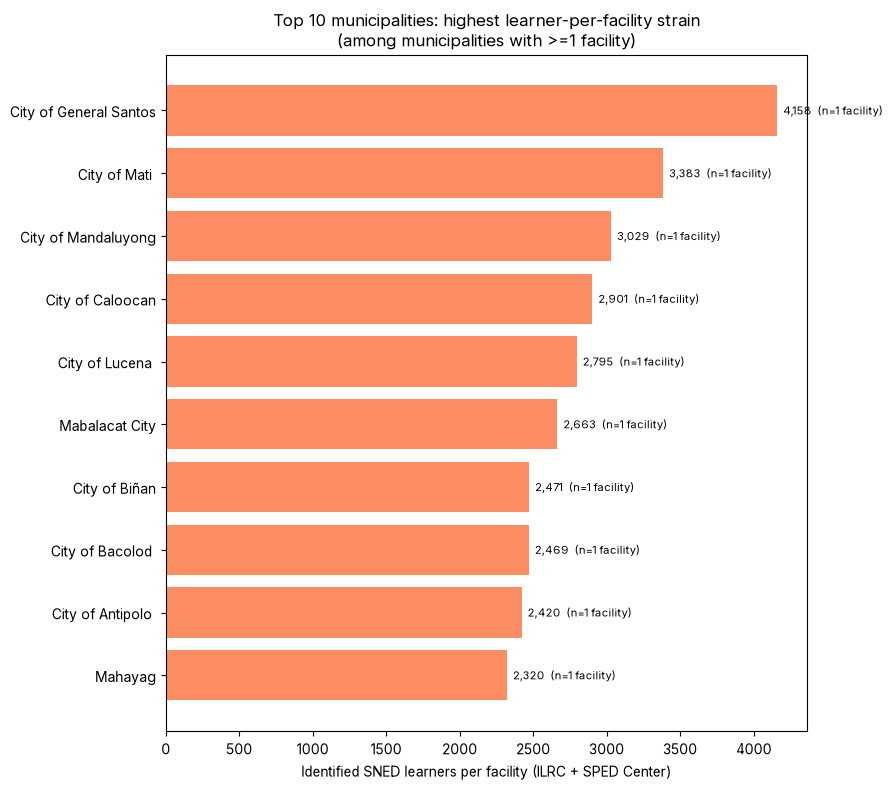

In [36]:
TOP_N_STRAINED = 10  # adjust freely between 20 and 30 as needed

strained_munis = muni_base[
    (muni_base['n_facilities'] > 0) &
    (muni_base['n_learners_total'] >= MIN_LEARNERS_FOR_RANKING)  # same floor as Cell 19
].copy()
strained_munis['n_facilities_int'] = strained_munis['n_facilities'].astype(int)

top_strained = strained_munis.sort_values('facility_ratio', ascending=False).head(TOP_N_STRAINED)
print(f"Municipalities with >=1 ILRC/SPED Center, ranked by identified SNED learners per facility "
      f"(i.e., caseload each facility would carry if spread evenly):")
print(f"{len(strained_munis):,} municipalities qualify (>=1 facility, >= {MIN_LEARNERS_FOR_RANKING} learners); "
      f"showing top {TOP_N_STRAINED}.")
display(top_strained[['psgc_municity_name', 'psgc_province_name', 'region_short',
                       'n_learners_total', 'n_facilities_int', 'facility_ratio']])

# Literal "'some', not zero" reading: restrict to municipalities running on just 1-2 facilities.
narrowly_resourced = strained_munis[strained_munis['n_facilities_int'].between(1, 2)]
print(f"\nOf these, {len(narrowly_resourced):,} are running on just 1-2 facilities total -- "
      f"the sharpest 'some facilities, grossly outnumbered' cases:")
display(narrowly_resourced.sort_values('facility_ratio', ascending=False).head(TOP_N_STRAINED)
        [['psgc_municity_name', 'psgc_province_name', 'region_short',
          'n_learners_total', 'n_facilities_int', 'facility_ratio']])

# Visual
plot_df = top_strained.sort_values('facility_ratio', ascending=True)
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(plot_df['psgc_municity_name'], plot_df['facility_ratio'], color=CAT_HIGHLIGHT)
ax.set_xlabel('Identified SNED learners per facility (ILRC + SPED Center)')
ax.set_title(f'Top {TOP_N_STRAINED} municipalities: highest learner-per-facility strain\n(among municipalities with >=1 facility)')
for i, (ratio, nfac) in enumerate(zip(plot_df['facility_ratio'], plot_df['n_facilities_int'])):
    suffix = 'y' if nfac == 1 else 'ies'
    ax.text(ratio, i, f"  {ratio:,.0f}  (n={nfac} facilit{suffix})", va='center', fontsize=8)
plt.tight_layout()
# plt.savefig('strained_facilities_top_munis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [37]:
# facility_ratio uses the STRICT definition (ILRC + SPED Center only). 
# This adds the parallel INCLUSIVE ratio.
muni_base['facility_ratio_incl_sned'] = np.where(
    muni_base['n_facilities_incl_sned'] > 0,
    muni_base['n_learners_total'] / muni_base['n_facilities_incl_sned'], np.nan
)

strained_munis = muni_base[
    (muni_base['n_facilities'] > 0) &
    (muni_base['n_learners_total'] >= MIN_LEARNERS_FOR_RANKING)
].copy()
strained_munis['n_facilities_int'] = strained_munis['n_facilities'].astype(int)
strained_munis['n_facilities_incl_sned_int'] = strained_munis['n_facilities_incl_sned'].astype(int)

top_strained_strict = strained_munis.sort_values('facility_ratio', ascending=False).head(TOP_N_STRAINED)
print(f"--- STRICT definition (ILRC + SPED Center only) ---")
display(top_strained_strict[['psgc_municity_name', 'region_short', 'n_learners_total',
                              'n_facilities_int', 'facility_ratio']])

strained_munis_incl = muni_base[
    (muni_base['n_facilities_incl_sned'] > 0) &
    (muni_base['n_learners_total'] >= MIN_LEARNERS_FOR_RANKING)
].copy()
strained_munis_incl['n_facilities_incl_sned_int'] = strained_munis_incl['n_facilities_incl_sned'].astype(int)
top_strained_incl = strained_munis_incl.sort_values('facility_ratio_incl_sned', ascending=False).head(TOP_N_STRAINED)
print(f"\n--- INCLUSIVE definition (+ SNED-implementing schools) ---")
display(top_strained_incl[['psgc_municity_name', 'region_short', 'n_learners_total',
                            'n_facilities_incl_sned_int', 'facility_ratio_incl_sned']])

# Which municipalities appear in the strict "grossly outnumbered" list but DROP OUT
# once SNED-implementing schools are counted -- i.e., their apparent strain is really
# a facility-TYPE gap (no ILRC/SPED Center specifically), not a facility gap overall.
strict_set = set(top_strained_strict['psgc_municity_name'])
incl_set = set(top_strained_incl['psgc_municity_name'])
only_strict = strict_set - incl_set
print(f"\n{len(only_strict)} of the top {TOP_N_STRAINED} strict-definition municipalities drop out of the "
      f"top {TOP_N_STRAINED} once SNED-implementing schools count: {sorted(only_strict)}")
print("These are places with an ILRC/SPED Center capacity gap specifically, even though a "
      "SNED-implementing school exists nearby -- a meaningfully different policy story from a "
      "place with literally nothing at all.")


--- STRICT definition (ILRC + SPED Center only) ---


,psgc_municity_name,region_short,n_learners_total,n_facilities_int,facility_ratio
1371,City of General Santos,SOCCSKSARGEN,4158.0,1,4158.0
148,City of Mati,Davao Region,3383.0,1,3383.0
433,City of Mandaluyong,NCR,3029.0,1,3029.0
1639,City of Caloocan,NCR,2901.0,1,2901.0
541,City of Lucena,CALABARZON,2795.0,1,2795.0
350,Mabalacat City,Central Luzon,2663.0,1,2663.0
448,City of Biñan,CALABARZON,2471.0,1,2471.0
855,City of Bacolod,NIR,2469.0,1,2469.0
517,City of Antipolo,CALABARZON,2420.0,1,2420.0
1176,Mahayag,Zamboanga Peninsula,2320.0,1,2320.0



--- INCLUSIVE definition (+ SNED-implementing schools) ---


,psgc_municity_name,region_short,n_learners_total,n_facilities_incl_sned_int,facility_ratio_incl_sned
1201,Roseller Lim,Zamboanga Peninsula,2162.0,1,2162.0
148,City of Mati,Davao Region,3383.0,2,1691.5
861,City of Sagay,NIR,3138.0,2,1569.0
132,San Fabian,Ilocos Region,1473.0,1,1473.0
66,Pili,Bicol Region,1377.0,1,1377.0
958,City of Talisay,Central Visayas,2720.0,2,1360.0
126,Mangaldan,Ilocos Region,1342.0,1,1342.0
963,City of Lapu-Lapu,Central Visayas,1325.0,1,1325.0
643,Buhi,Bicol Region,1308.0,1,1308.0
241,San Mariano,Cagayan Valley,1263.0,1,1263.0



9 of the top 10 strict-definition municipalities drop out of the top 10 once SNED-implementing schools count: ['City of Antipolo ', 'City of Bacolod ', 'City of Biñan', 'City of Caloocan', 'City of General Santos', 'City of Lucena ', 'City of Mandaluyong', 'Mabalacat City', 'Mahayag']
These are places with an ILRC/SPED Center capacity gap specifically, even though a SNED-implementing school exists nearby -- a meaningfully different policy story from a place with literally nothing at all.


### **F. Exports**

In [38]:
# EXPORT — four full rankings, saved to DATA / "exports".
EXPORT_DIR = DATA / "exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

DIV_RATIO_COLS = ['region_label', 'division', 'n_learners_total', 'n_filled', 'current_ratio',
                  'n_authorized', 'potential_ratio_if_fully_staffed']

# 1-2. Divisions, Elementary / JHS, by CURRENT ratio (FULL population, min. 1 authorized) — full.
for lvl, fname in [('Elementary', 'q3_div_elementary_current_ratio_full.csv'),
                    ('Junior High School', 'q3_div_jhs_current_ratio_full.csv')]:
    out = (density_by_level[(density_by_level['school_level'] == lvl) &
                            (density_by_level['n_authorized'] >= MIN_AUTH)]
           .sort_values('current_ratio', ascending=False)
           [DIV_RATIO_COLS]
           .reset_index(drop=True))
    out.to_csv(EXPORT_DIR / fname, index=False)
    print(f"Saved {len(out):,} rows -> {EXPORT_DIR / fname}")

# 3. STRICT definition facility ratio ranking — full (Cell 24's strained_munis).
strict_full = (strained_munis
               .sort_values('facility_ratio', ascending=False)
               [['psgc_municity_name', 'region_short', 'n_learners_total',
                 'n_facilities_int', 'facility_ratio']]
               .reset_index(drop=True))
strict_full.to_csv(EXPORT_DIR / "q3_muni_facility_ratio_strict_full.csv", index=False)
print(f"Saved {len(strict_full):,} rows -> {EXPORT_DIR / 'q3_muni_facility_ratio_strict_full.csv'}")

# 4. INCLUSIVE definition facility ratio ranking — full (Cell 24's strained_munis_incl).
incl_full = (strained_munis_incl
             .sort_values('facility_ratio_incl_sned', ascending=False)
             [['psgc_municity_name', 'region_short', 'n_learners_total',
               'n_facilities_incl_sned_int', 'facility_ratio_incl_sned']]
             .reset_index(drop=True))
incl_full.to_csv(EXPORT_DIR / "q3_muni_facility_ratio_inclusive_full.csv", index=False)
print(f"Saved {len(incl_full):,} rows -> {EXPORT_DIR / 'q3_muni_facility_ratio_inclusive_full.csv'}")


Saved 209 rows -> c:\Users\Lanz Railey Fermin\Desktop\ecair_work\sned-analysis\data\exports\q3_div_elementary_current_ratio_full.csv
Saved 142 rows -> c:\Users\Lanz Railey Fermin\Desktop\ecair_work\sned-analysis\data\exports\q3_div_jhs_current_ratio_full.csv
Saved 399 rows -> c:\Users\Lanz Railey Fermin\Desktop\ecair_work\sned-analysis\data\exports\q3_muni_facility_ratio_strict_full.csv
Saved 1,077 rows -> c:\Users\Lanz Railey Fermin\Desktop\ecair_work\sned-analysis\data\exports\q3_muni_facility_ratio_inclusive_full.csv
